# Simulated data analysis
This notebook inspects the simulated export for the streaming video static-trial implementation.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 50
base = Path("/workspace/challenges/video-recording-static-trials/attempts/2026-06-14-13-52/evidence/simulated_data/regular/basic_data")
trial_df = pd.read_csv(base / "trial.csv")
participant_df = pd.read_csv(base / "participant.csv")
trial_df.head()

,id,participant_id,animal,block,answer_choice,answer_choice_label,answer_recording_hash,definition_recording_hash,recording_object_key,recording_object_url,upload_status,upload_http_status,bytes_streamed,chunks_streamed,recording_started_at,recording_stopped_at,recording_error_code,recording_error_message,score
0,17,8,dogs,B,a_little,A little,NaN,ea53bb544baabe8f6c29de83be2e7631bf7fd3f8,streaming-static-trials/ea53bb544baabe8f6c29de...,https://video-recording-test-292651677991.s3.a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,1,1,fish,C,not_at_all,Not at all,NaN,98191b4ddb2d6a3cd74fa90ed3e3140a6c7a3403,streaming-static-trials/98191b4ddb2d6a3cd74fa9...,https://video-recording-test-292651677991.s3.a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,3,2,dogs,A,not_at_all,Not at all,NaN,10f94392d3ad0d519e91be0ef8a1c47f9a751493,streaming-static-trials/10f94392d3ad0d519e91be...,https://video-recording-test-292651677991.s3.a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,6,4,cats,A,not_at_all,Not at all,NaN,629c44806848dab44e342f6a04a7be688847cd25,streaming-static-trials/629c44806848dab44e342f...,https://video-recording-test-292651677991.s3.a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,2,2,ponies,A,very_much,Very much,NaN,82244a27ada9795ca86fdbfff22616c5077c0ba3,streaming-static-trials/82244a27ada9795ca86fdb...,https://video-recording-test-292651677991.s3.a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [2]:
summary = {
    "n_participants": len(participant_df),
    "n_trials": len(trial_df),
    "n_unique_recording_hashes": trial_df["definition_recording_hash"].nunique(),
    "n_missing_recording_hashes": int(trial_df["definition_recording_hash"].isna().sum()),
}
pd.DataFrame([summary])

,n_participants,n_trials,n_unique_recording_hashes,n_missing_recording_hashes
0,12,35,34,0


In [3]:
choice_counts = trial_df["answer_choice_label"].fillna("(missing)").value_counts().rename_axis("choice").reset_index(name="count")
choice_counts

,choice,count
0,A little,14
1,Not at all,12
2,Very much,9


In [4]:
block_score = trial_df.groupby("block", dropna=False)["score"].mean().reset_index(name="mean_score")
block_score

,block,mean_score
0,A,0.666667
1,B,0.692308
2,C,0.571429


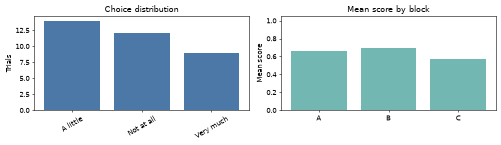

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].bar(choice_counts["choice"], choice_counts["count"], color="#4c78a8")
axes[0].set_title("Choice distribution")
axes[0].set_ylabel("Trials")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(block_score["block"], block_score["mean_score"], color="#72b7b2")
axes[1].set_title("Mean score by block")
axes[1].set_ylabel("Mean score")
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## Interpretation
- The simulated export contains participant/trial rows with non-missing trial-level recording hash metadata.
- Bot simulations do not produce browser recording uploads, so upload-status fields can be empty in simulated basic data.
- Behavioral trial outcomes remain valid across blocks, indicating the static task flow continues to function after adding the streaming uploader integration.